In [274]:
import networkx as nx 
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import EoN
from tqdm import trange
import seaborn as sns
import pandas as pd
import random
import matplotlib as mpl
from scipy.spatial import ConvexHull

In [2]:
dire = "../../long_sw_100000_fin/"
sw = pd.read_csv('../test_files.csv').iloc[::10].values

dire_ba = "../../new_ba_100000/"
ba = pd.read_csv('../ba_test_files.csv').iloc[::10].values

In [3]:
import glob
sw_files = glob.glob(dire+'p*.csv')
ba_files = glob.glob(dire_ba+'p*.csv')
len(ba_files),len(sw_files)

(72000, 72000)

In [6]:
dire_ba+file

'../../new_ba_100000/../../new_ba_100000\\p_0.11_0.3_0.2_0.0001_0.21000000000000002_seed_0.csv'

0 1471
CPU times: total: 2min 9s
Wall time: 3min 29s


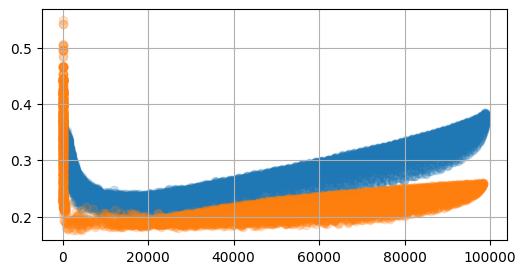

In [8]:
%%time
fig, axes = plt.subplots(1,1, figsize=(6,3),squeeze=False)
ax = axes.flatten()

ba_df = []
sw_df = []
ba_0 = 0
sw_0 = 0
for i,file in enumerate(ba_files[::10]):
    _, beta, gc,dc, initi, alpha, _, seed = file.split('\\')[-1].split('_')
    df = pd.read_csv(file, usecols=['S','E'])
    temp = df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    df['incidence'] = df['incidence'].fillna(0)
    
    #v_{ij} = (- sum_i (p_{ij}*log(p_{ij}))  )^{-1}
    # p_{ij} == K/N == sick on i / total sick on all i
    total_inc = df.incidence.sum()
    if total_inc == 0:
        ba_0+=1
    else:    
        p_ij = df.incidence / total_inc
        log_pij = np.log(p_ij+1e-10)
        v_ij = (-np.sum(p_ij*log_pij))**(-1)
        
        ba_df.append([total_inc, v_ij, alpha, beta, 'ba'])
        ax[0].scatter(total_inc, v_ij, color='tab:blue', alpha=.2)

        
for i,file in enumerate(sw_files[::10]):
    _, beta, gc,dc, initi, alpha, _, seed = file.split('\\')[-1].split('_')
    df = pd.read_csv(file, usecols=['S','E'])
    temp = df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    df['incidence'] = df['incidence'].fillna(0)
    
    #v_{ij} = (- sum_i (p_{ij}*log(p_{ij}))  )^{-1}
    # p_{ij} == K/N == sick on i / total sick on all i
    total_inc = df.incidence.sum()
    if total_inc <= 10:
        sw_0 += 1
    else:
        p_ij = df.incidence / total_inc
        log_pij = np.log(p_ij+1e-10)
        v_ij = (-np.sum(p_ij*log_pij))**(-1)
        sw_df.append([total_inc, v_ij, alpha, beta, 'sw'])
        ax[0].scatter(total_inc, v_ij, color='tab:orange', alpha=.2)

ba_df = pd.DataFrame(ba_df, columns=['total_inc','v','alpha','beta','name'])  
sw_df = pd.DataFrame(sw_df, columns=['total_inc','v','alpha','beta','name']) 
print(ba_0, sw_0)
ax[0].grid() 

In [74]:
all_df = pd.concat([ba_df, sw_df])
all_df.v.min(), all_df.v.max()

(np.float64(0.1764805568910674), np.float64(0.5494276139689521))

In [75]:
all_df['v_norm'] = (all_df.v - all_df.v.min())/all_df.v.max()

<Axes: xlabel='total_inc', ylabel='v_norm'>

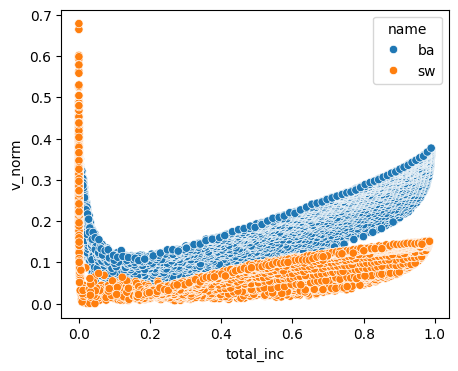

In [76]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=all_df['total_inc']/100000, y=all_df['v_norm'], 
                hue=all_df['name'])

<Axes: xlabel='total_inc', ylabel='v_norm'>

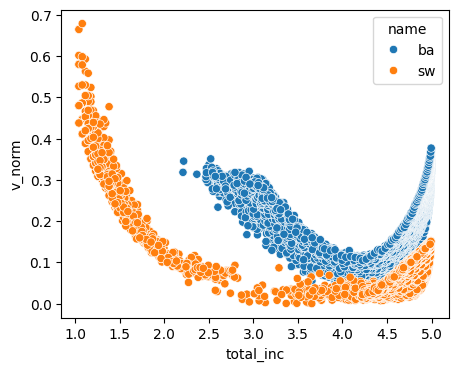

In [10]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=np.log10(all_df['total_inc']), y=all_df['v_norm'], 
                hue=all_df['name'])

<Axes: xlabel='total_inc', ylabel='v_norm'>

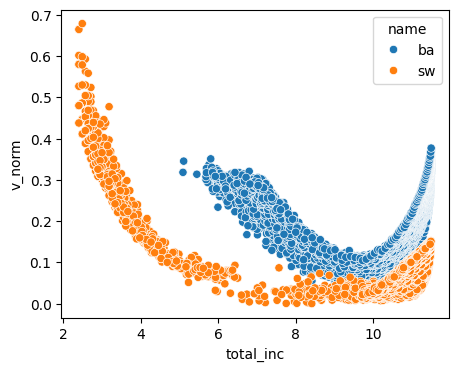

In [9]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=np.log(all_df['total_inc']), y=all_df['v_norm'], 
                hue=all_df['name'])

In [ ]:
1

In [12]:
all_df['alpha'].astype(float)*all_df['beta'].astype(float)

0       0.0231
1       0.0242
2       0.0253
3       0.0264
4       0.0275
         ...  
5724    0.8640
5725    0.8730
5726    0.8820
5727    0.8910
5728    0.8100
Length: 12929, dtype: float64

<Axes: xlabel='None', ylabel='v_norm'>

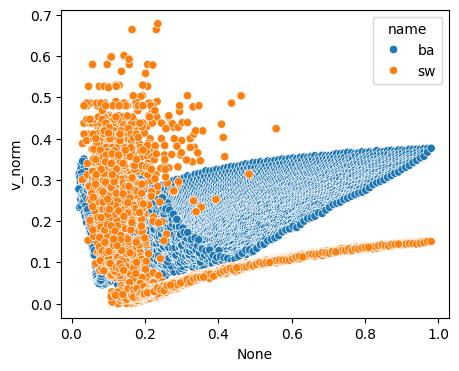

In [13]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=(all_df['alpha'].astype(float)*all_df['beta'].astype(float)
                  ), y=all_df['v_norm'], 
                hue=all_df['name'])

<Axes: xlabel='None', ylabel='total_inc'>

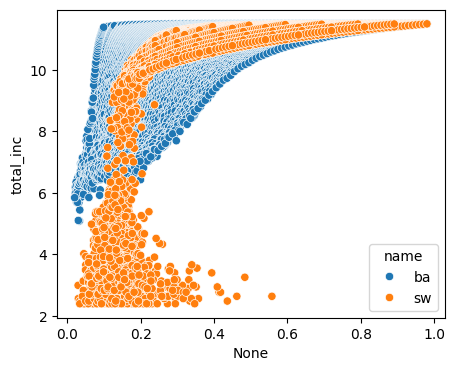

In [15]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=(all_df['alpha'].astype(float)*all_df['beta'].astype(float)
                  ), y=np.log(all_df['total_inc']), 
                hue=all_df['name'])

<Axes: xlabel='None', ylabel='total_inc'>

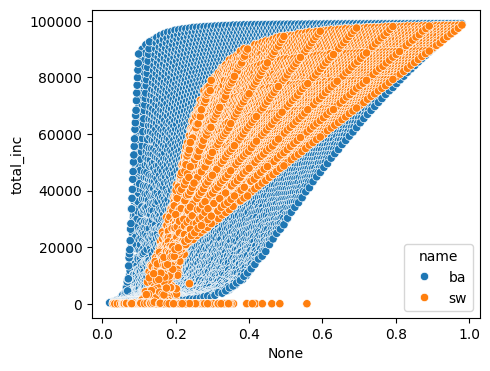

In [16]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=(all_df['alpha'].astype(float)*all_df['beta'].astype(float)
                  ), y=all_df['total_inc'], 
                hue=all_df['name'])

In [235]:
17282+24972+48865 + 333581

424700

In [266]:
609+1026+662+2310

4607

In [162]:
df_c.shape

(31926, 20)

In [267]:
df_c = pd.read_excel('data1990_2019.xlsx')
df_c = df_c[(df_c.cld_year >= 2009)&(df_c.cld_year < 2020)]

# qty_total - qty_15
# remove people older than 15, because children's data has less underreporting
df_c['qty_lt15'] = df_c['qty_total'] - df_c['qty_15']
df_c['wd_lt15'] = df_c['wd_total'] - df_c['wd_15']

# we combine [40w:52w] year x  AND  [0w:20w] year x+1
df_c = df_c[~((df_c.cld_year == 2009)&(df_c.week_number < 40))]
df_c = df_c[~((df_c.cld_year == 2019)&(df_c.week_number > 20))]
df_c = df_c[((df_c.week_number >= 40)|(df_c.week_number <= 20))]
df_c = df_c[['town_name','cld_year','week_number','qty_lt15','wd_lt15','qty_total','qty_15','wd_total','wd_15']]
df_c['years_part'] = ''

for i in np.arange(2009,2019):
    df_c.loc[((df_c.cld_year == i)&(df_c.week_number >=40)
             )|((df_c.cld_year == i+1)&(df_c.week_number <=20)), 
             'years_part'] = f'{i}{i+1}'
    
df_c.head()

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010


<Axes: >

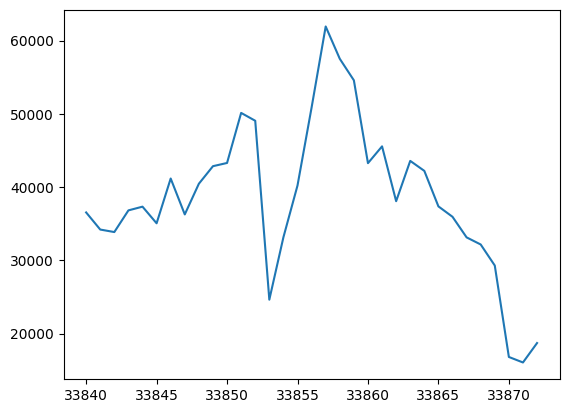

In [263]:
i=2018
df_c[(df_c['years_part']==f'{i}{i+1}')&(df_c['town_name']=='Москва')].wd_lt15.plot()

In [319]:
df_c.iloc[:33]

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010
1035,Архангельск,2009,45,49907.0,1589.0,354682.0,304775.0,2469.0,880.0,20092010
1036,Архангельск,2009,46,49907.0,2259.0,354682.0,304775.0,3875.0,1616.0,20092010
1037,Архангельск,2009,47,49907.0,4096.0,354682.0,304775.0,7506.0,3410.0,20092010
1038,Архангельск,2009,48,49907.0,5280.0,354682.0,304775.0,9141.0,3861.0,20092010
1039,Архангельск,2009,49,49907.0,4229.0,354682.0,304775.0,7217.0,2988.0,20092010


In [320]:
df_c.iloc[:33].wd_lt15.sum()

np.float64(64928.0)

In [330]:
all_total = df_c.groupby(['town_name','years_part']).agg({'wd_lt15':'sum', 'qty_lt15':'mean',
                                                         'wd_total':'sum','qty_total':'mean'}
                                          ).rename(columns={'wd_total':'total_inc_year_adults',
                                                            'qty_total':'pop_year_adults',
                                                            'wd_lt15':'total_inc_year_kids',
                                                            'qty_lt15':'pop_year_kids'})
all_total

total_inc_year_kids  pop_year_kids  \
town_name   years_part                                       
Архангельск 20092010                64928.0   49926.393939   
            20102011                59105.0   50993.545455   
            20112012                58352.0   51679.000000   
            20122013                63881.0   52194.294118   
            20132014                56163.0   55313.181818   
...                                     ...            ...   
Якутск      20142015                72300.0   65666.424242   
            20152016                86947.0   68763.000000   
            20162017                94857.0   71206.121212   
            20172018               100456.0   72228.000000   
            20182019               109748.0   73434.060606   

                        total_inc_year_adults  pop_year_adults  
town_name   years_part                                          
Архангельск 20092010                 100857.0    354403.212121  
            20102011                  90731.0    354235.939394  
            20112012                  92089.0    354245.000000  
            20122013                 101920.0    355585.000000  
            20132014                  81602.0    338335.727273  
...                                       ...              ...  
Якутск      20142015                  83175.0    320259.636364  
            20152016                 103336.0    327998.575758  
            20162017                 111772.0    332178.272727  
            20172018                 113403.0    333730.000000  
            20182019                 128705.0    336670.606061  

[510 rows x 4 columns]

In [331]:
df_fin = df_c.merge(all_total, how='left', left_on=['town_name','years_part'], right_index=True)
df_fin.head()

,town_name,cld_year,week_number,qty_lt15,wd_lt15,qty_total,qty_15,wd_total,wd_15,years_part,total_inc_year_kids,pop_year_kids,total_inc_year_adults,pop_year_adults
1030,Архангельск,2009,40,49907.0,1610.0,354682.0,304775.0,2569.0,959.0,20092010,64928.0,49926.393939,100857.0,354403.212121
1031,Архангельск,2009,41,49907.0,1364.0,354682.0,304775.0,2201.0,837.0,20092010,64928.0,49926.393939,100857.0,354403.212121
1032,Архангельск,2009,42,49907.0,1535.0,354682.0,304775.0,2279.0,744.0,20092010,64928.0,49926.393939,100857.0,354403.212121
1033,Архангельск,2009,43,49907.0,1635.0,354682.0,304775.0,2312.0,677.0,20092010,64928.0,49926.393939,100857.0,354403.212121
1034,Архангельск,2009,44,49907.0,1627.0,354682.0,304775.0,2406.0,779.0,20092010,64928.0,49926.393939,100857.0,354403.212121


In [332]:
all_p_ij_kids = df_fin.wd_lt15 / df_fin.total_inc_year_kids
df_fin['p_times_logp_kids'] = all_p_ij_kids*np.log(all_p_ij_kids)

all_p_ij_adults = df_fin.wd_total / df_fin.total_inc_year_adults
df_fin['p_times_logp_adults'] = all_p_ij_adults*np.log(all_p_ij_adults)
#spb_intn =  
all_intn = df_fin.groupby(['town_name','years_part'
                          ]).agg({'p_times_logp_kids':lambda x: (-x.sum())**(-1),
                                'p_times_logp_adults':lambda x: (-x.sum())**(-1)})
all_intn

C:\Users\user\AppData\Local\Temp\ipykernel_18024\4221852715.py:8: RuntimeWarning: divide by zero encountered in scalar power
  ]).agg({'p_times_logp_kids':lambda x: (-x.sum())**(-1),
C:\Users\user\AppData\Local\Temp\ipykernel_18024\4221852715.py:9: RuntimeWarning: divide by zero encountered in scalar power
  'p_times_logp_adults':lambda x: (-x.sum())**(-1)})


p_times_logp_kids  p_times_logp_adults
town_name   years_part                                        
Архангельск 20092010             0.294342             0.296846
            20102011             0.289462             0.290472
            20112012             0.288915             0.289516
            20122013             0.288111             0.288800
            20132014             0.288725             0.288871
...                                   ...                  ...
Якутск      20142015             0.289116             0.289228
            20152016             0.288106             0.289929
            20162017             0.290066             0.291046
            20172018             0.285597             0.285565
            20182019             0.289027             0.289539

[510 rows x 2 columns]

In [333]:
all_plot = all_total.reset_index().merge(all_intn.reset_index())
all_plot

,town_name,years_part,total_inc_year_kids,pop_year_kids,total_inc_year_adults,pop_year_adults,p_times_logp_kids,p_times_logp_adults
0,Архангельск,20092010,64928.0,49926.393939,100857.0,354403.212121,0.294342,0.296846
1,Архангельск,20102011,59105.0,50993.545455,90731.0,354235.939394,0.289462,0.290472
2,Архангельск,20112012,58352.0,51679.000000,92089.0,354245.000000,0.288915,0.289516
3,Архангельск,20122013,63881.0,52194.294118,101920.0,355585.000000,0.288111,0.288800
4,Архангельск,20132014,56163.0,55313.181818,81602.0,338335.727273,0.288725,0.288871
...,...,...,...,...,...,...,...,...
505,Якутск,20142015,72300.0,65666.424242,83175.0,320259.636364,0.289116,0.289228
506,Якутск,20152016,86947.0,68763.000000,103336.0,327998.575758,0.288106,0.289929
507,Якутск,20162017,94857.0,71206.121212,111772.0,332178.272727,0.290066,0.291046
508,Якутск,20172018,100456.0,72228.000000,113403.0,333730.000000,0.285597,0.285565


In [308]:
chosen.town_name.unique()

array(['Воронеж', 'Краснодар', 'Москва', 'Самара', 'Санкт-Петербург',
       'Челябинск'], dtype=object)

C:\Users\user\AppData\Local\Temp\ipykernel_18024\3732806707.py:11: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.scatterplot(x = chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}']),


Text(0.5, 1.0, 'kids')

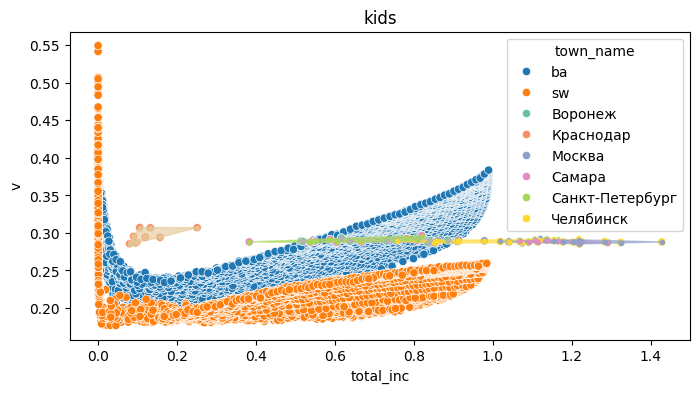

In [350]:
fig,ax = plt.subplots(1,1, figsize=(8,4))

chosen = all_plot[all_plot.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
cmap = mpl.colormaps['Set2']
colors = list(cmap(np.linspace(0, 1, 8)))

who = 'kids'
sns.scatterplot(x=all_df['total_inc']/100000, y=all_df['v'], 
                hue=all_df['name'])
sns.scatterplot(x = chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}']),
               y = chosen[f'p_times_logp_{who}'], hue = chosen['town_name'], palette=colors)
    
for city in chosen.town_name.unique():
    xa = chosen[chosen.town_name==city][f'total_inc_year_{who}'
                                       ]/chosen[chosen.town_name==city][f'pop_year_{who}']
    ya = chosen[chosen.town_name==city][f'p_times_logp_{who}']
    hull = ConvexHull(pd.concat([xa, ya], axis=1))

    
    col = colors.pop()
    ax.scatter(xa,ya, marker='.', alpha=.9, 
               zorder=10, color=col)

    ax.fill(xa.iloc[hull.vertices], ya.iloc[hull.vertices], 
            alpha=.6, color=col, label=city)
ax.set_title(who)

C:\Users\user\AppData\Local\Temp\ipykernel_18024\3508018083.py:11: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.scatterplot(x = chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}']),


Text(0.5, 1.0, 'adults')

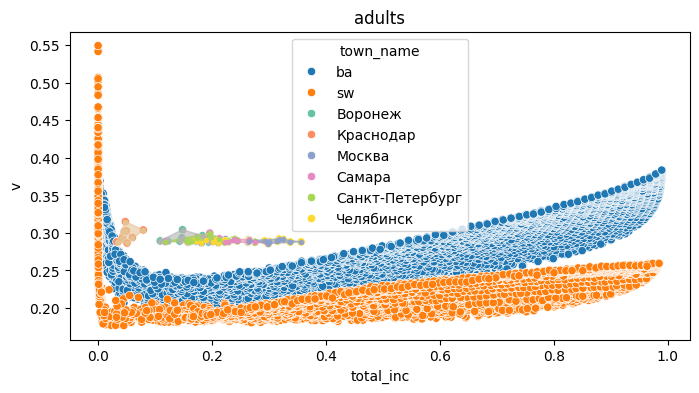

In [349]:
fig,ax = plt.subplots(1,1, figsize=(8,4))

chosen = all_plot[all_plot.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
cmap = mpl.colormaps['Set2']
colors = list(cmap(np.linspace(0, 1, 8)))

who = 'adults'
sns.scatterplot(x=all_df['total_inc']/100000, y=all_df['v'], 
                hue=all_df['name'])
sns.scatterplot(x = chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}']),
               y = chosen[f'p_times_logp_{who}'], hue = chosen['town_name'], palette=colors)
    
for city in chosen.town_name.unique():
    xa = chosen[chosen.town_name==city][f'total_inc_year_{who}'
                                       ]/chosen[chosen.town_name==city][f'pop_year_{who}']
    ya = chosen[chosen.town_name==city][f'p_times_logp_{who}']
    hull = ConvexHull(pd.concat([xa, ya], axis=1))

    
    col = colors.pop()
    ax.scatter(xa,ya, marker='.', alpha=.9, 
               zorder=10, color=col)

    ax.fill(xa.iloc[hull.vertices], ya.iloc[hull.vertices], 
            alpha=.6, color=col, label=city)
ax.set_title(who)

C:\Users\user\AppData\Local\Temp\ipykernel_18024\1522436394.py:9: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.scatterplot(x = np.log(chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}'])),


Text(0.5, 1.0, 'kids')

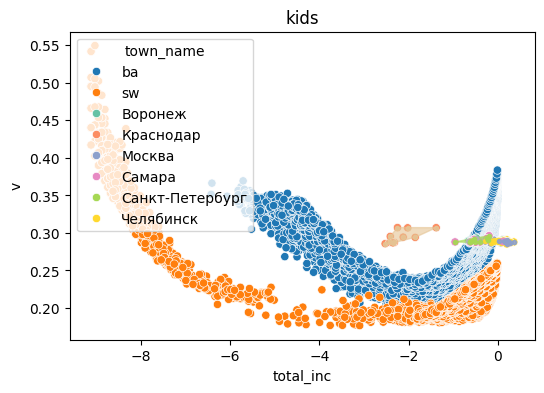

In [355]:
who = 'kids'
chosen = all_plot[all_plot.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
fig,ax = plt.subplots(1,1, figsize=(6,4))
cmap = mpl.colormaps['Set2']
colors = list(cmap(np.linspace(0, 1, 8)))
sns.scatterplot(x=np.log(all_df['total_inc']/100000), y=all_df['v'], 
                hue=all_df['name'], ax=ax)
sns.scatterplot(x = np.log(chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}'])),
               y = chosen[f'p_times_logp_{who}'], hue = chosen['town_name'], 
                palette=colors, ax=ax)

for city in chosen.town_name.unique():
    xa = np.log(chosen[chosen.town_name==city][f'total_inc_year_{who}'
                                       ]/chosen[chosen.town_name==city][f'pop_year_{who}'])
    ya = chosen[chosen.town_name==city][f'p_times_logp_{who}']
    hull = ConvexHull(pd.concat([xa, ya], axis=1))

    
    col = colors.pop()
    ax.scatter(xa,ya, marker='.', alpha=.9, 
               zorder=10, color=col)

    ax.fill(xa.iloc[hull.vertices], ya.iloc[hull.vertices], 
            alpha=.6, color=col, label=city)
ax.set_title(who)

ax.set_title(who)

C:\Users\user\AppData\Local\Temp\ipykernel_18024\3935832895.py:9: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.scatterplot(x = np.log(chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}'])),


Text(0.5, 1.0, 'adults')

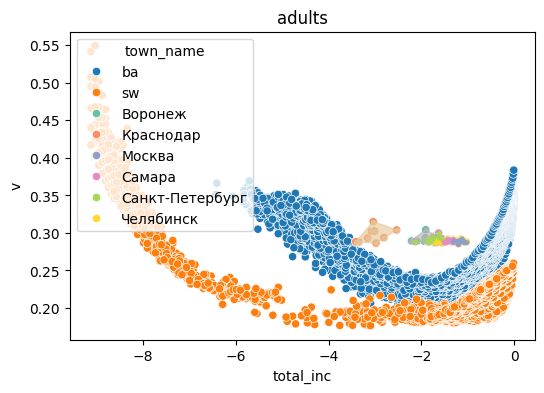

In [356]:
who = 'adults'
chosen = all_plot[all_plot.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
fig,ax = plt.subplots(1,1, figsize=(6,4))
cmap = mpl.colormaps['Set2']
colors = list(cmap(np.linspace(0, 1, 8)))
sns.scatterplot(x=np.log(all_df['total_inc']/100000), y=all_df['v'], 
                hue=all_df['name'], ax=ax)
sns.scatterplot(x = np.log(chosen[f'total_inc_year_{who}']/(chosen[f'pop_year_{who}'])),
               y = chosen[f'p_times_logp_{who}'], hue = chosen['town_name'], 
                palette=colors, ax=ax)

for city in chosen.town_name.unique():
    xa = np.log(chosen[chosen.town_name==city][f'total_inc_year_{who}'
                                       ]/chosen[chosen.town_name==city][f'pop_year_{who}'])
    ya = chosen[chosen.town_name==city][f'p_times_logp_{who}']
    hull = ConvexHull(pd.concat([xa, ya], axis=1))

    
    col = colors.pop()
    ax.scatter(xa,ya, marker='.', alpha=.9, 
               zorder=10, color=col)

    ax.fill(xa.iloc[hull.vertices], ya.iloc[hull.vertices], 
            alpha=.6, color=col, label=city)
ax.set_title(who)

ax.set_title(who)

Text(0.5, 0, 'Total inc / population')

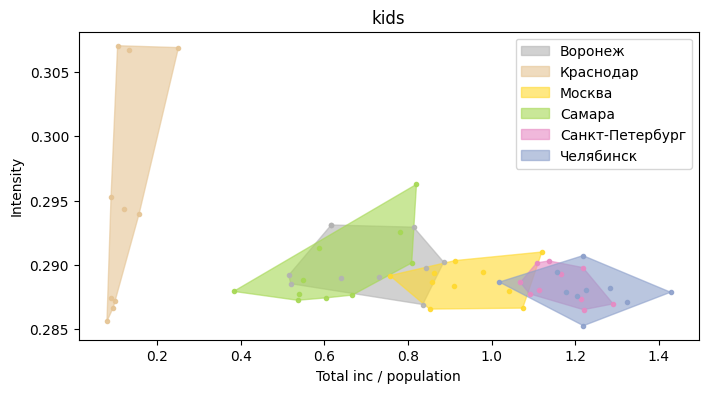

In [346]:
fig,ax = plt.subplots(1,1, figsize=(8,4))
cmap = mpl.colormaps['Set2']
colors = list(cmap(np.linspace(0, 1, 8)))
who = 'kids'    
for city in chosen.town_name.unique():
    xa = chosen[chosen.town_name==city][f'total_inc_year_{who}'
                                       ]/chosen[chosen.town_name==city][f'pop_year_{who}']
    ya = chosen[chosen.town_name==city][f'p_times_logp_{who}']
    hull = ConvexHull(pd.concat([xa, ya], axis=1))

    
    col = colors.pop()
    ax.scatter(xa,ya, marker='.', alpha=.9, 
               zorder=10, color=col)

    ax.fill(xa.iloc[hull.vertices], ya.iloc[hull.vertices], 
            alpha=.6, color=col, label=city)
ax.legend()

ax.set_title(who)
ax.set_ylabel('Intensity')
ax.set_xlabel('Total inc / population')

Text(0.5, 0, 'Total inc / population')

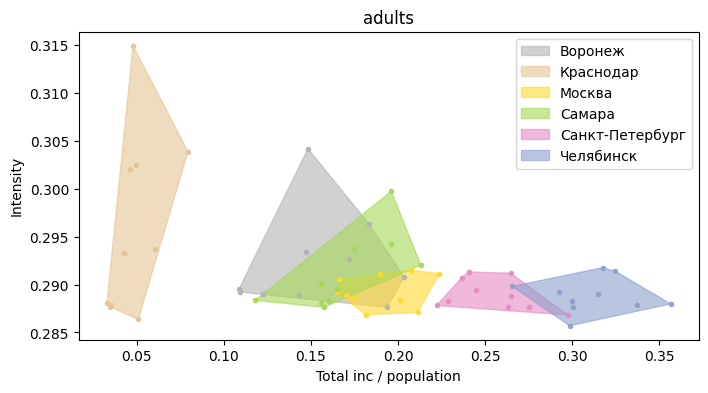

In [345]:
fig,ax = plt.subplots(1,1, figsize=(8,4))
cmap = mpl.colormaps['Set2']
colors = list(cmap(np.linspace(0, 1, 8)))
who = 'adults'    
for city in chosen.town_name.unique():
    xa = chosen[chosen.town_name==city][f'total_inc_year_{who}'
                                       ]/chosen[chosen.town_name==city][f'pop_year_{who}']
    ya = chosen[chosen.town_name==city][f'p_times_logp_{who}']
    hull = ConvexHull(pd.concat([xa, ya], axis=1))

    
    col = colors.pop()
    ax.scatter(xa,ya, marker='.', alpha=.9, 
               zorder=10, color=col)

    ax.fill(xa.iloc[hull.vertices], ya.iloc[hull.vertices], 
            alpha=.6, color=col, label=city)
ax.legend()

ax.set_title(who)
ax.set_ylabel('Intensity')
ax.set_xlabel('Total inc / population')

<Axes: xlabel='None', ylabel='p_times_logp'>

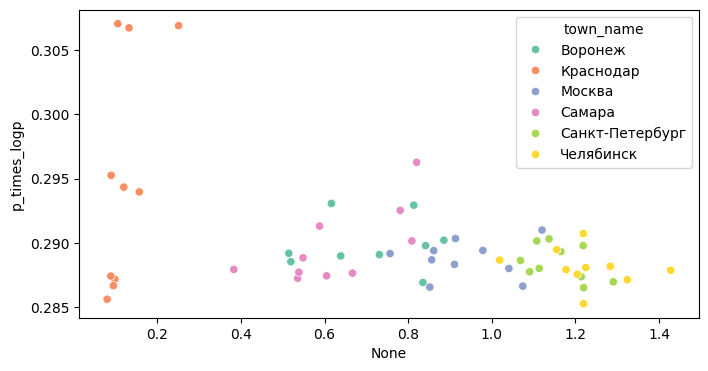

In [271]:
chosen = all_plot[all_plot.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
plt.subplots(figsize=(8,4))

sns.scatterplot(x = chosen.total_inc_year/chosen.pop_year,
               y = chosen.p_times_logp, hue = chosen.town_name, palette='Set2')

In [258]:
df_fin

,town_name,cld_year,week_number,qty_lt15,wd_lt15,years_part,total_inc_year,pop_year,p_times_logp
1030,Архангельск,2009,40,49907.0,1610.0,20092010,64928.0,49926.393939,-0.091675
1031,Архангельск,2009,41,49907.0,1364.0,20092010,64928.0,49926.393939,-0.081150
1032,Архангельск,2009,42,49907.0,1535.0,20092010,64928.0,49926.393939,-0.088532
1033,Архангельск,2009,43,49907.0,1635.0,20092010,64928.0,49926.393939,-0.092710
1034,Архангельск,2009,44,49907.0,1627.0,20092010,64928.0,49926.393939,-0.092379
...,...,...,...,...,...,...,...,...,...
82378,Якутск,2019,16,74218.0,3422.0,20182019,109748.0,73434.060606,-0.108133
82379,Якутск,2019,17,74218.0,2832.0,20182019,109748.0,73434.060606,-0.094373
82380,Якутск,2019,18,74218.0,2186.0,20182019,109748.0,73434.060606,-0.078003
82381,Якутск,2019,19,74218.0,2065.0,20182019,109748.0,73434.060606,-0.074756


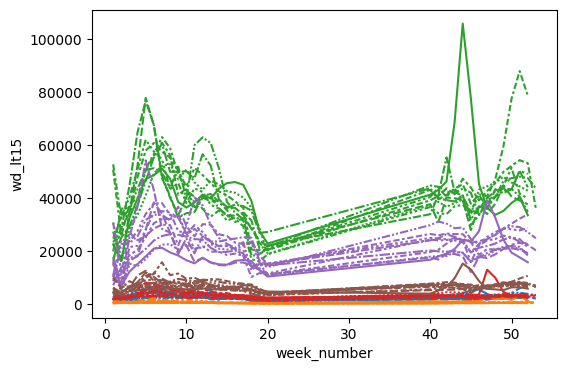

In [261]:
plt.subplots(figsize=(6,4))
temp = df_fin[df_fin.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
sns.lineplot(x=temp.week_number, y=temp.wd_lt15, hue=temp.town_name, style=temp.years_part)
plt.legend([],[], frameon=False)

In [84]:
all_total = df_c.groupby(['town_name','cld_year']).agg({'wd_total':'sum', 'qty_total':'mean'}
                                          ).rename(columns={'wd_total':'total_inc_year',
                                                            'qty_total':'pop_year'})
all_total

total_inc_year  pop_year
town_name   cld_year                          
Архангельск 2009            126752.0  354682.0
            2010            103494.0  354222.0
            2011            115456.0  354245.0
            2012            118123.0  354245.0
            2013            112128.0  356523.0
...                              ...       ...
Якутск      2016            138370.0  329791.0
            2017            141454.0  333730.0
            2018            145025.0  333730.0
            2019             95068.0  338582.0
            2020                 0.0       NaN

[612 rows x 2 columns]

In [89]:
df_fin = df_c.merge(all_total, how='left', left_on=['town_name','cld_year'], right_index=True)
df_fin

,town_name,cld_year,week_number,wd_total,wda_total,qty_total,total_inc_year,pop_year
991,Архангельск,2009,1,1095.0,NaN,354682.0,126752.0,354682.0
992,Архангельск,2009,2,881.0,NaN,354682.0,126752.0,354682.0
993,Архангельск,2009,3,1847.0,NaN,354682.0,126752.0,354682.0
994,Архангельск,2009,4,2239.0,NaN,354682.0,126752.0,354682.0
995,Архангельск,2009,5,2798.0,NaN,354682.0,126752.0,354682.0
...,...,...,...,...,...,...,...,...
82462,Якутск,2020,48,NaN,NaN,NaN,0.0,NaN
82463,Якутск,2020,49,NaN,NaN,NaN,0.0,NaN
82464,Якутск,2020,50,NaN,NaN,NaN,0.0,NaN
82465,Якутск,2020,51,NaN,NaN,NaN,0.0,NaN


In [92]:
all_p_ij = df_fin.wd_total / df_fin.total_inc_year
df_fin['p_times_logp'] = all_p_ij*np.log(all_p_ij)
#spb_intn =  
all_intn = df_fin.groupby(['town_name','cld_year']).agg({'p_times_logp':lambda x: (-x.sum())**(-1)})
all_intn

C:\Users\user\anaconda3\envs\abm_seir\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\user\AppData\Local\Temp\ipykernel_18024\333863657.py:4: RuntimeWarning: divide by zero encountered in scalar power
  all_intn = df_fin.groupby(['town_name','cld_year']).agg({'p_times_logp':lambda x: (-x.sum())**(-1)})


p_times_logp
town_name   cld_year              
Архангельск 2009          0.270040
            2010          0.260791
            2011          0.262340
            2012          0.259630
            2013          0.265605
...                            ...
Якутск      2016          0.259587
            2017          0.261643
            2018          0.259176
            2019          0.308924
            2020              -inf

[612 rows x 1 columns]

In [98]:
all_plot = all_total.reset_index().merge(all_intn.reset_index())
all_plot

,town_name,cld_year,total_inc_year,pop_year,p_times_logp
0,Архангельск,2009,126752.0,354682.0,0.270040
1,Архангельск,2010,103494.0,354222.0,0.260791
2,Архангельск,2011,115456.0,354245.0,0.262340
3,Архангельск,2012,118123.0,354245.0,0.259630
4,Архангельск,2013,112128.0,356523.0,0.265605
...,...,...,...,...,...
607,Якутск,2016,138370.0,329791.0,0.259587
608,Якутск,2017,141454.0,333730.0,0.261643
609,Якутск,2018,145025.0,333730.0,0.259176
610,Якутск,2019,95068.0,338582.0,0.308924


<Axes: xlabel='total_inc', ylabel='v'>

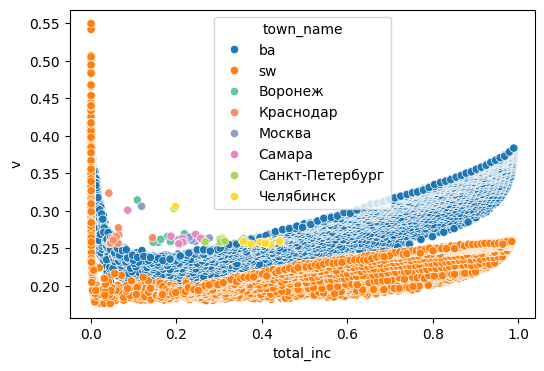

In [117]:
chosen = all_plot[all_plot.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
plt.subplots(figsize=(6,4))
sns.scatterplot(x=all_df['total_inc']/100000, y=all_df['v'], 
                hue=all_df['name'])
sns.scatterplot(x = chosen.total_inc_year/(chosen.pop_year),
               y = chosen.p_times_logp, hue = chosen.town_name, palette='Set2')

<Axes: xlabel='total_inc_year', ylabel='p_times_logp'>

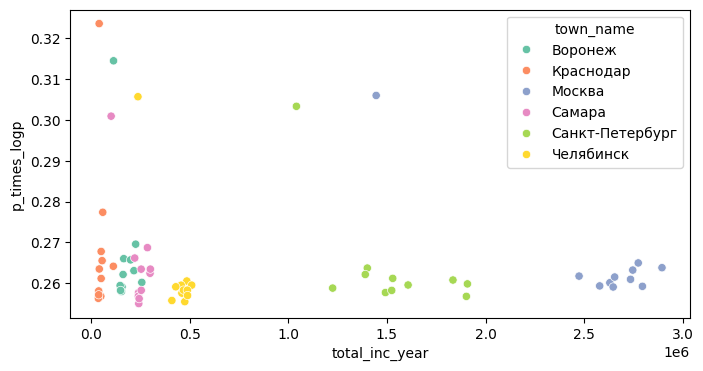

In [118]:
chosen = all_plot[all_plot.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
plt.subplots(figsize=(8,4))

sns.scatterplot(x = chosen.total_inc_year,#/chosen.pop_year,
               y = chosen.p_times_logp, hue = chosen.town_name, palette='Set2')

<Axes: xlabel='week_number', ylabel='wd_total'>

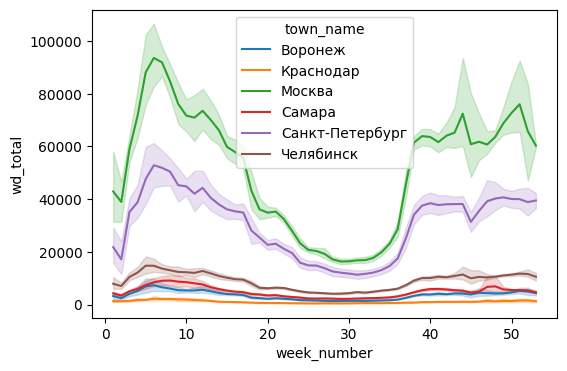

In [139]:
plt.subplots(figsize=(6,4))
temp = df_fin[df_fin.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
sns.lineplot(x=temp.week_number, y=temp.wd_total, hue=temp.town_name)


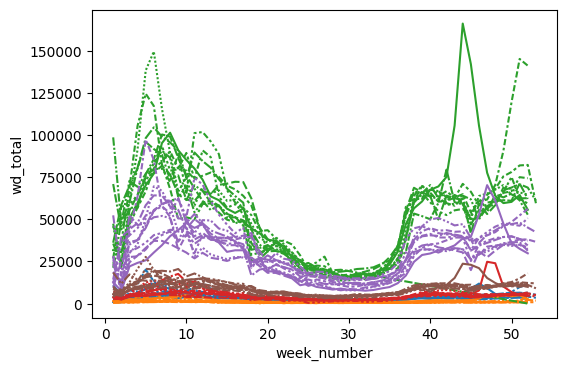

In [137]:
plt.subplots(figsize=(6,4))
temp = df_fin[df_fin.town_name.isin(['Москва','Санкт-Петербург','Самара','Челябинск',
                                          'Краснодар','Воронеж'])]
sns.lineplot(x=temp.week_number, y=temp.wd_total, hue=temp.town_name, style=temp.cld_year)
plt.legend([],[], frameon=False)

<Axes: >

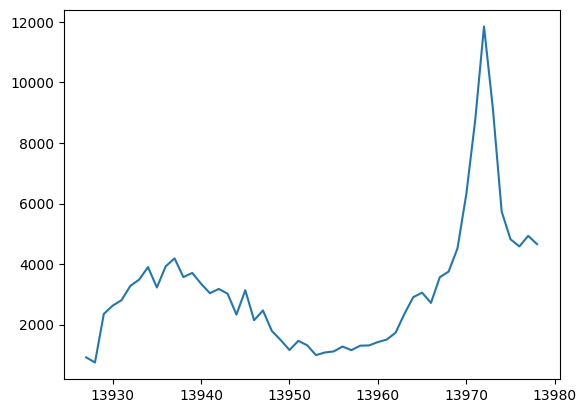

In [147]:
temp.iloc[:52].wd_total.plot()

<Axes: xlabel='total_inc', ylabel='v'>

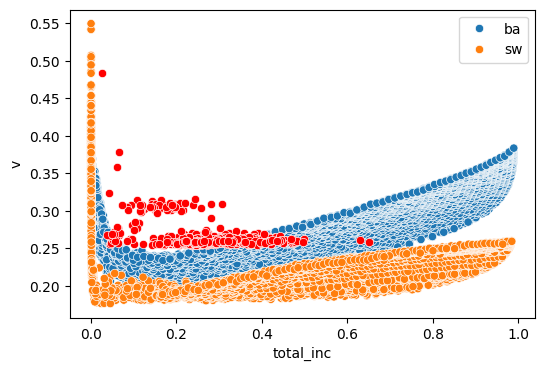

In [107]:
plt.subplots(figsize=(6,4))
sns.scatterplot(x=all_df['total_inc']/100000, y=all_df['v'], 
                hue=all_df['name'])
sns.scatterplot(x = all_plot.total_inc_year/all_plot.pop_year,
               y = all_plot.p_times_logp, color='red')

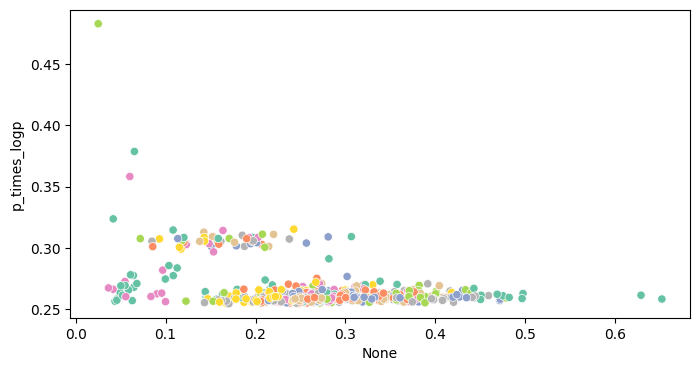

In [124]:
plt.subplots(figsize=(8,4))

sns.scatterplot(x = all_plot.total_inc_year/all_plot.pop_year,
               y = all_plot.p_times_logp, hue = all_plot.town_name, palette='Set2')
plt.legend([],[], frameon=False)

In [62]:
df_spb = df_c[(df_c.town_name == 'Санкт-Петербург')]
df_spb.head()

,town_name,cld_year,week_number,wd_total,wda_total,qty_total
55969,Санкт-Петербург,2009,1,12740.0,NaN,4568047.0
55970,Санкт-Петербург,2009,2,7420.0,NaN,4568047.0
55971,Санкт-Петербург,2009,3,22043.0,NaN,4568047.0
55972,Санкт-Петербург,2009,4,24160.0,NaN,4568047.0
55973,Санкт-Петербург,2009,5,25654.0,NaN,4568047.0


In [63]:
spb_total = df_spb.groupby('cld_year').agg({'wd_total':'sum', 'qty_total':'mean'}
                                          ).rename(columns={'wd_total':'total_inc_year',
                                                            'qty_total':'pop_year'})
spb_total

,total_inc_year,pop_year
cld_year,,
2009,1400549.0,4568047.0
2010,1224767.0,4581854.0
2011,1390210.0,4600276.0
2012,1492373.0,4899344.0
2013,1529445.0,4953219.0
2014,1524305.0,5028000.0
2015,1607295.0,5131942.0
2016,1834826.0,5191690.0
2017,1902902.0,5225690.0


In [ ]:
 #v_{ij} = (- sum_i (p_{ij}*log(p_{ij}))  )^{-1}
    # p_{ij} == K/N == sick on i / total sick on all i

In [64]:
df_spb = df_spb.merge(spb_total, how='left', left_on='cld_year', right_index=True)
spb_p_ij = df_spb.wd_total / df_spb.total_inc_year
df_spb['p_times_logp'] = spb_p_ij*np.log(spb_p_ij)
df_spb

,town_name,cld_year,week_number,wd_total,wda_total,qty_total,total_inc_year,pop_year,p_times_logp
55969,Санкт-Петербург,2009,1,12740.0,NaN,4568047.0,1400549.0,4568047.0,-0.042752
55970,Санкт-Петербург,2009,2,7420.0,NaN,4568047.0,1400549.0,4568047.0,-0.027763
55971,Санкт-Петербург,2009,3,22043.0,NaN,4568047.0,1400549.0,4568047.0,-0.065342
55972,Санкт-Петербург,2009,4,24160.0,NaN,4568047.0,1400549.0,4568047.0,-0.070035
55973,Санкт-Петербург,2009,5,25654.0,NaN,4568047.0,1400549.0,4568047.0,-0.073267
...,...,...,...,...,...,...,...,...,...
56590,Санкт-Петербург,2020,48,NaN,NaN,NaN,0.0,NaN,NaN
56591,Санкт-Петербург,2020,49,NaN,NaN,NaN,0.0,NaN,NaN
56592,Санкт-Петербург,2020,50,NaN,NaN,NaN,0.0,NaN,NaN
56593,Санкт-Петербург,2020,51,NaN,NaN,NaN,0.0,NaN,NaN


In [69]:
spb_intn =  df_spb.groupby('cld_year').agg({'p_times_logp':lambda x: (-x.sum())**(-1)})
spb_intn

C:\Users\user\AppData\Local\Temp\ipykernel_18024\1661509942.py:1: RuntimeWarning: divide by zero encountered in scalar power
  spb_intn =  df_spb.groupby('cld_year').agg({'p_times_logp':lambda x: (-x.sum())**(-1)})


,p_times_logp
cld_year,
2009,0.263681
2010,0.258770
2011,0.262109
2012,0.257681
2013,0.261151
2014,0.258204
2015,0.259531
2016,0.260750
2017,0.256738


<Axes: xlabel='total_inc', ylabel='v'>

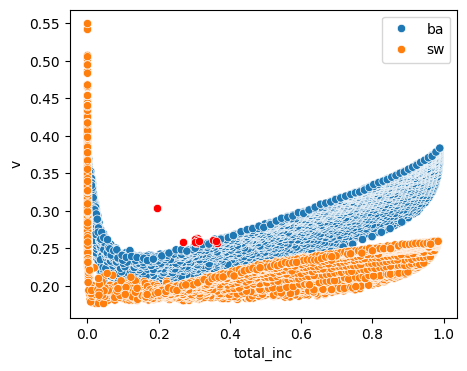

In [80]:
plt.subplots(figsize=(5,4))
sns.scatterplot(x=all_df['total_inc']/100000, y=all_df['v'], 
                hue=all_df['name'])
sns.scatterplot(x = spb_total.total_inc_year/spb_total.pop_year,
               y = spb_intn.p_times_logp, color='red')

In [71]:
spb_total.total_inc_year/spb_total.pop_year

cld_year
2009    0.306597
2010    0.267308
2011    0.302201
2012    0.304607
2013    0.308778
2014    0.303163
2015    0.313194
2016    0.353416
2017    0.364144
2018    0.361298
2019    0.194504
2020         NaN
dtype: float64

<Axes: >

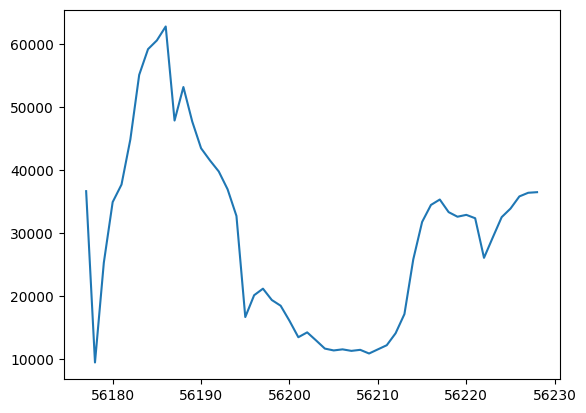

In [28]:
i=4
df_spb.wd_total.iloc[i*52:i*52+52].plot()